In [2]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt


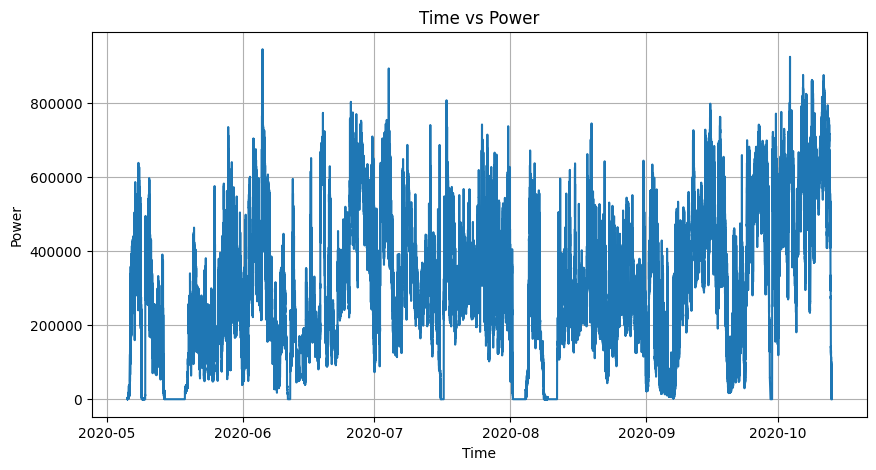

2020-05-05 15:56:00+00:00
2020-10-13 05:21:40+00:00
693618


In [ ]:
# Plot the cluster power demand

import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

df = pd.read_csv("csvs/cluster_power_only_nodes.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

print(df["time"][0])
print(df["time"].iloc[-1])
print(len(df)) 
# df_10days.to_csv("cluster_power_only_nodes_30days.csv", index=False)

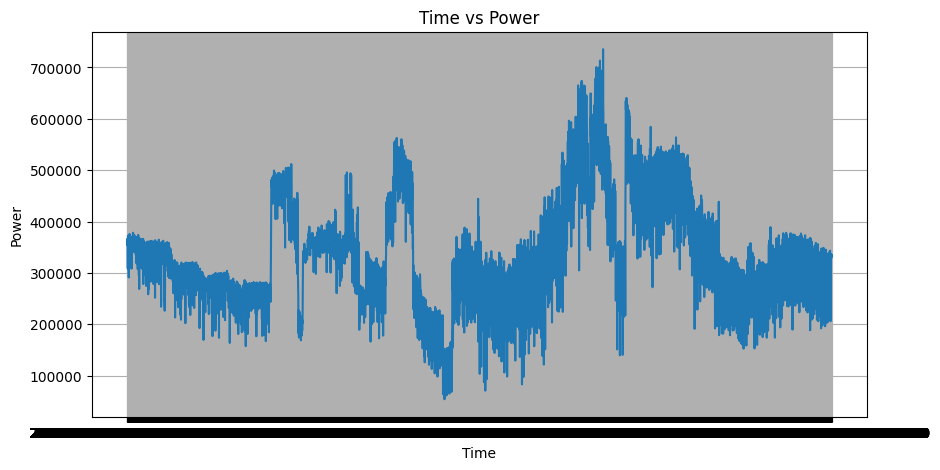

In [ ]:
# plot the power request for every t

import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
df = pd.read_csv("cluster_power_only_nodes_10days.csv")
df_first = df[8641:12960]
plt.figure(figsize=(10, 5))
plt.plot(df_first["time"], df_first["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

In [1]:
### Simulation 0 ###

# In this simulation, no battery is available.
# We evaluate the total cost and CO2 emissions when the whole demand
# is supplied by the grid under a maximum grid-power threshold.
# If the requested grid power exceeds the threshold, the excess energy
# is charged at the higher electricity price.

import pandas as pd

from utils.co2 import CarbonIntensityModels
from utils.price_model import PriceModel


# Grid-power thresholds to evaluate, in W
list_thresholds = [200000, 300000, 400000, 500000]


# Load the power trace
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")
# df = pd.read_csv("cluster_power_only_nodes.csv")


# Parse timestamps and compute the duration of each time step in hours
df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)


# Add time-varying electricity prices
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# Add time-varying grid carbon intensity
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)
# df["co2_intensity"] = cm.co2_fixed(df)


# Evaluate the grid-only policy for each threshold
for threshold in list_thresholds:
    total_cost = 0.0
    total_co2 = 0.0

    for _, row in df.iterrows():
        cost_low = row["price_base"]
        cost_high = row["price_high"]
        co2_g_per_kwh = row["co2_intensity"]

        power = row["power"]        # W
        dt = row["dt_hours"]        # h

        if dt <= 0:
            continue

        # Energy below the threshold is charged at the base price.
        # Energy above the threshold is charged at the peak price.
        e_base = min(power, threshold) * dt
        e_peak = max(power - threshold, 0) * dt

        total_cost += (e_base * cost_low) + (e_peak * cost_high)
        total_co2 += ((e_base + e_peak) / 1000) * co2_g_per_kwh

    print("---------------")
    print("with threshold =", threshold)
    print(f"Total cost: {total_cost:.2f} EUR")
    print(f"Total CO2: {total_co2 / 1000:.2f} kg CO2")

---------------
with threshold = 200000
Total cost: 58258.98 EUR
Total CO2: 67248.18 kg CO2
---------------
with threshold = 300000
Total cost: 50310.71 EUR
Total CO2: 67248.18 kg CO2
---------------
with threshold = 400000
Total cost: 45901.31 EUR
Total CO2: 67248.18 kg CO2
---------------
with threshold = 500000
Total cost: 43595.40 EUR
Total CO2: 67248.18 kg CO2


---------------
SIMULATION 1 - BATTERY PEAK SHAVING
with threshold = 200000
with battery capacity = 1600000
Total cost with battery: 59642.40 EUR
Total CO2: 69844.281 kg
Final battery charge: 167650.13 Wh
Final SOC: 14.97 %
Remaining battery capacity: 1120000.00 Wh
Total energy charged into the battery: 10004921.06 Wh
Total energy discharged from the battery: 9614887.05 Wh
---------------
SIMULATION 1 - BATTERY PEAK SHAVING
with threshold = 200000
with battery capacity = 3200000
Total cost with battery: 59145.30 EUR
Total CO2: 69806.081 kg
Final battery charge: 376761.90 Wh
Final SOC: 14.97 %
Remaining battery capacity: 2516494.26 Wh
Total energy charged into the battery: 13411087.01 Wh
Total energy discharged from the battery: 13232685.45 Wh
---------------
SIMULATION 1 - BATTERY PEAK SHAVING
with threshold = 200000
with battery capacity = 6400000
Total cost with battery: 58431.95 EUR
Total CO2: 69668.855 kg
Final battery charge: 832567.64 Wh
Final SOC: 14.97 %
Remaining battery capac

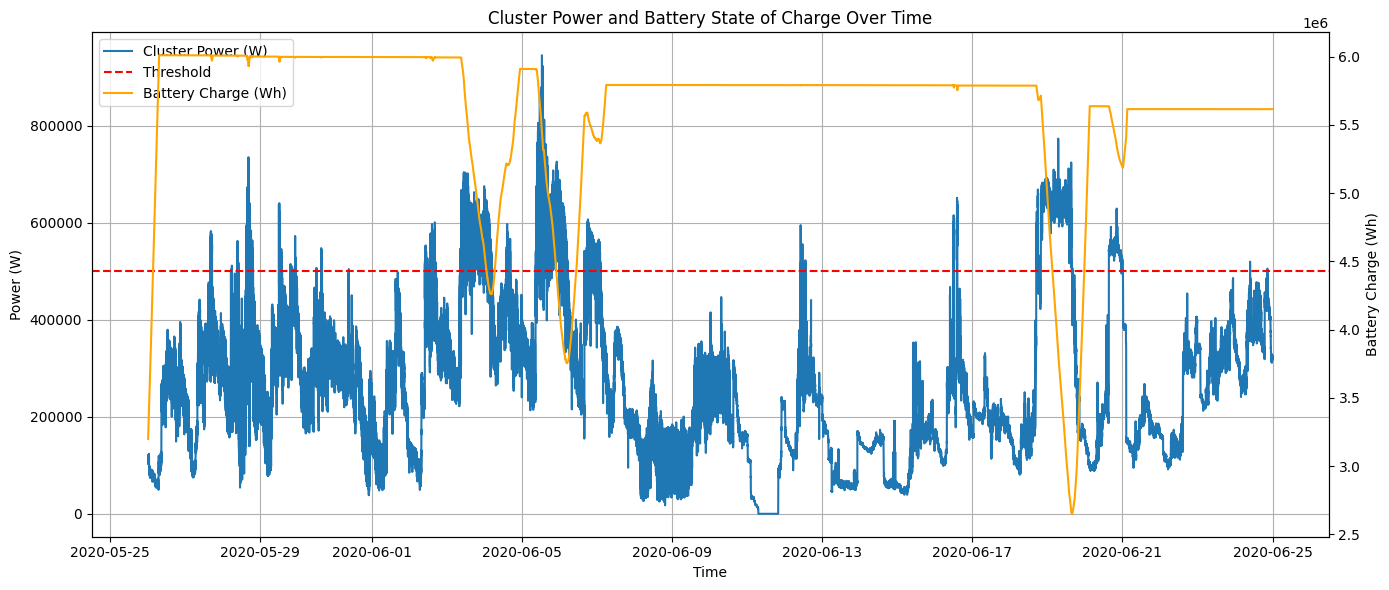

In [2]:
### Simulation 1 ###

# Battery used for peak shaving:
# - when the load is above the grid threshold, the battery discharges to reduce the peak;
# - when the load is below the grid threshold, the battery charges using the available margin below the threshold.
# This simulation does not yet implement a price-aware or carbon-aware dispatch policy.
#
# Battery usage costs and emissions are included.

import pandas as pd
import matplotlib.pyplot as plt

from utils.co2 import CarbonIntensityModels
from utils.battery_model import Battery
from utils.price_model import PriceModel


# ---------------------------
# PARAMETERS
# ---------------------------

# Grid-power thresholds to evaluate, in W
list_thresholds = [200000, 300000, 400000, 500000]

# Battery capacities to evaluate, in Wh
list_battery_capacity = [1_600_000, 3_200_000, 6_400_000]


# ---------------------------
# LOAD DATA
# ---------------------------

# Load the cluster power trace
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")

# Parse timestamps and compute the duration of each time step in hours
df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)


# ---------------------------
# ADD EXTERNAL SIGNALS
# ---------------------------

# Add time-varying electricity prices
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)

# Add time-varying grid carbon intensity
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)


# ---------------------------
# RUN SIMULATIONS
# ---------------------------

for THRESHOLD in list_thresholds:
    for BATTERY_CAPACITY in list_battery_capacity:

        # ---------------------------
        # INITIALIZATION
        # ---------------------------

        battery = Battery(
            capacity_wh=BATTERY_CAPACITY,
            initial_charge_wh=BATTERY_CAPACITY / 2,
            max_charge_rate_w=BATTERY_CAPACITY,
            max_discharge_rate_w=BATTERY_CAPACITY,
        )

        total_cost = 0.0
        total_co2_g = 0.0

        battery_history = []
        time_history = []
        grid_energy_history = []
        battery_charge_energy_history = []
        battery_discharge_energy_history = []
        cost_history = []
        co2_history_g = []


        # ---------------------------
        # SIMULATION LOOP
        # ---------------------------

        for _, row in df.iterrows():
            t = row["time"]
            dt = row["dt_hours"]

            if dt <= 0:
                battery_history.append(battery.energy)
                time_history.append(t)
                grid_energy_history.append(0.0)
                battery_charge_energy_history.append(0.0)
                battery_discharge_energy_history.append(0.0)
                cost_history.append(0.0)
                co2_history_g.append(0.0)
                continue

            power = row["power"]                  # W
            cost_low = row["price_base"]          # EUR/Wh
            cost_high = row["price_high"]         # EUR/Wh
            co2_g_per_kwh = row["co2_intensity"]  # gCO2/kWh

            # Energy required by the cluster
            E_load = power * dt


            # -----------------------------
            # CASE 1: power > threshold
            # The battery discharges to cover part of the peak demand.
            # -----------------------------

            if power > THRESHOLD:
                P_peak_request = power - THRESHOLD

                # Requested battery discharge power
                P_discharge = min(P_peak_request, THRESHOLD)
                E_from_batt = battery.discharge(P_discharge, dt)

                # Peak energy that would be required from the grid
                E_peak = max(power - THRESHOLD, 0.0) * dt

                # Peak energy still supplied by the grid after battery discharge
                E_peak_remaining = max(E_peak - E_from_batt, 0.0)

                # Base energy supplied by the grid
                E_base = THRESHOLD * dt

                # Total energy supplied by the grid
                E_from_grid = E_base + E_peak_remaining

                # Grid cost and emissions
                cost = E_base * cost_low + E_peak_remaining * cost_high
                co2_g = (E_from_grid / 1000.0) * co2_g_per_kwh

                E_charged = 0.0

                # Add battery usage cost and emissions
                cost += battery.step_cost(dt, E_from_batt)
                co2_g += battery.step_co2_g(dt, E_from_batt)


            # -----------------------------
            # CASE 2: power <= threshold
            # The battery charges using the available margin below the threshold.
            # -----------------------------

            else:
                E_from_batt = 0.0

                # Energy supplied by the grid to serve the load
                E_base = E_load

                # Available grid-power margin below the threshold
                P_available = THRESHOLD - power
                P_charge = min(P_available, THRESHOLD)

                # Energy effectively stored in the battery
                E_charged = battery.charge(P_charge, dt)

                # Both the load and the battery charging energy are supplied by the grid
                E_from_grid = E_base + E_charged

                # Grid cost and emissions
                cost = E_from_grid * cost_low
                co2_g = (E_from_grid / 1000.0) * co2_g_per_kwh

                # Add battery usage cost and emissions
                cost += battery.step_cost(dt, E_charged)
                co2_g += battery.step_co2_g(dt, E_charged)


            # ---------------------------
            # UPDATE ACCUMULATED METRICS
            # ---------------------------

            total_cost += cost
            total_co2_g += co2_g

            cost_history.append(cost)
            co2_history_g.append(co2_g)
            grid_energy_history.append(E_from_grid)
            battery_charge_energy_history.append(E_charged)
            battery_discharge_energy_history.append(E_from_batt)

            # Update slow battery dynamics
            battery.step(dt)

            # Store battery state after the time step
            battery_history.append(battery.energy)
            time_history.append(t)


        # ---------------------------
        # FINAL RESULTS
        # ---------------------------

        print("---------------")
        print("SIMULATION 1 - BATTERY PEAK SHAVING")
        print("with threshold =", THRESHOLD)
        print("with battery capacity =", BATTERY_CAPACITY)
        print(f"Total cost with battery: {total_cost:.2f} EUR")
        print(f"Total CO2: {total_co2_g / 1000:.3f} kg")
        print(f"Final battery charge: {battery.energy:.2f} Wh")
        print(f"Final SOC: {battery.soc * 100:.2f} %")
        print(f"Remaining battery capacity: {battery.capacity:.2f} Wh")
        print(f"Total energy charged into the battery: {sum(battery_charge_energy_history):.2f} Wh")
        print(f"Total energy discharged from the battery: {sum(battery_discharge_energy_history):.2f} Wh")


# ---------------------------
# PLOT
# ---------------------------

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.axhline(THRESHOLD, color="red", linestyle="--", label="Threshold")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

plt.title("Cluster Power and Battery State of Charge Over Time")

lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()

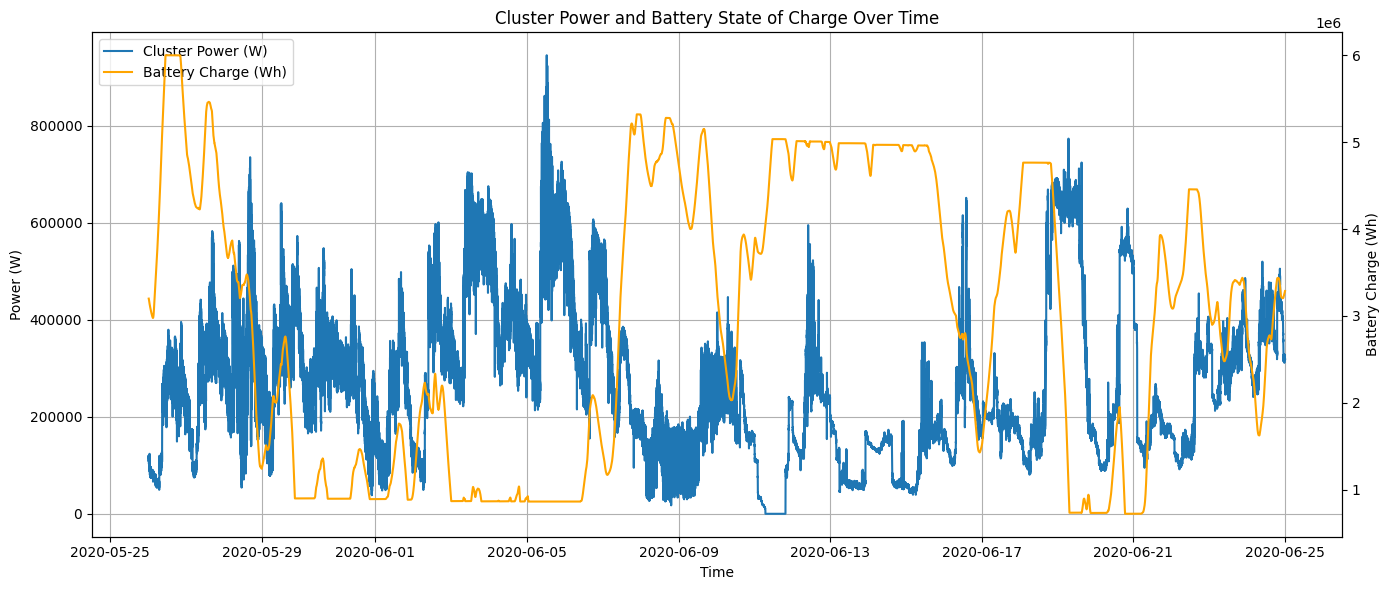

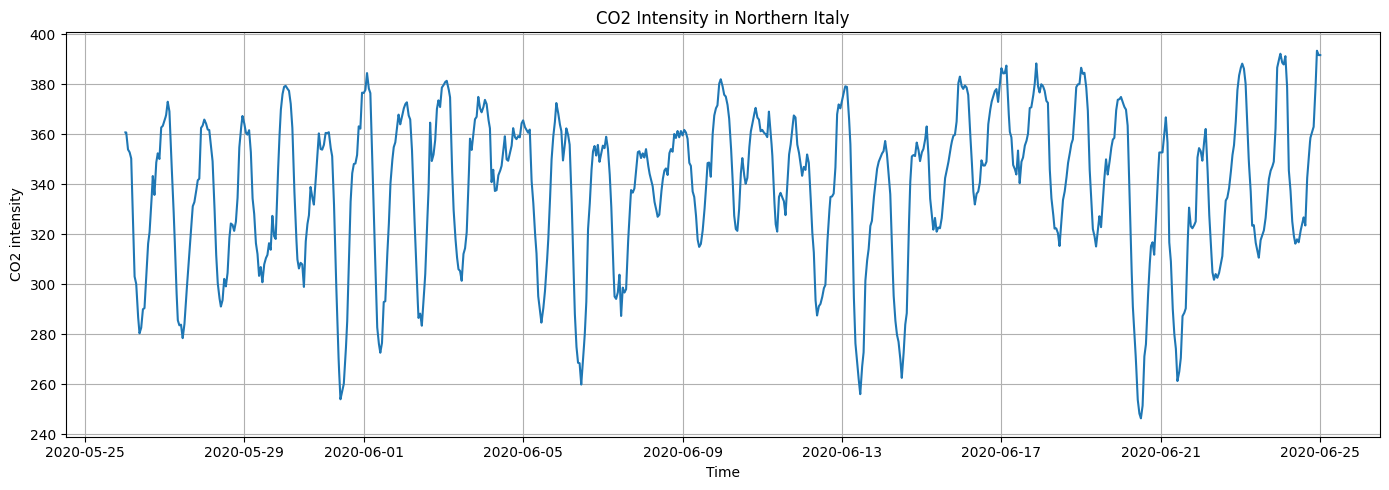

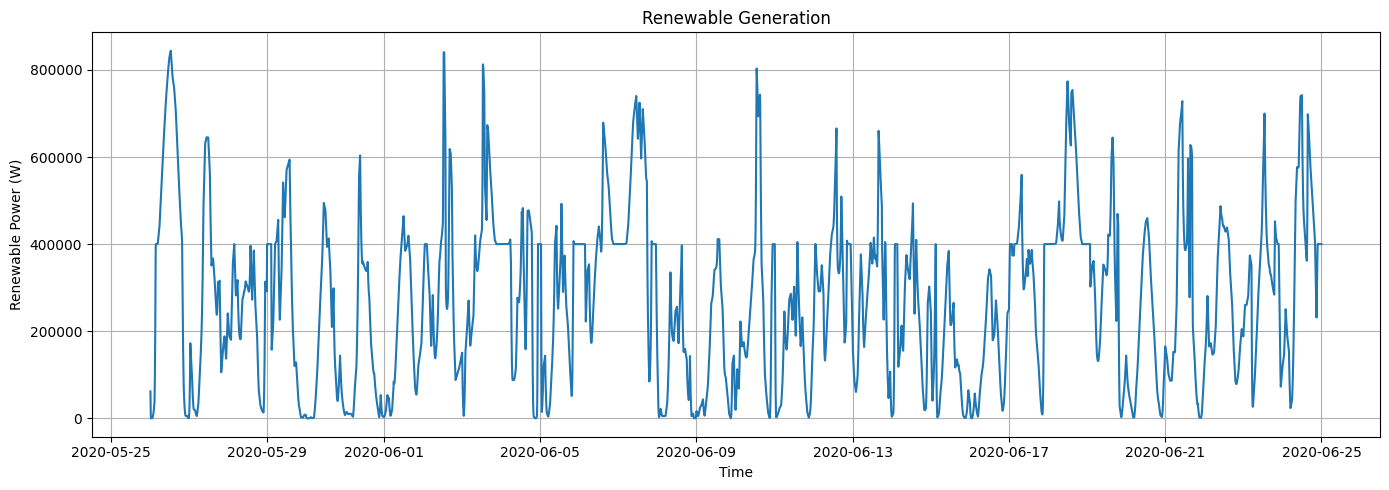

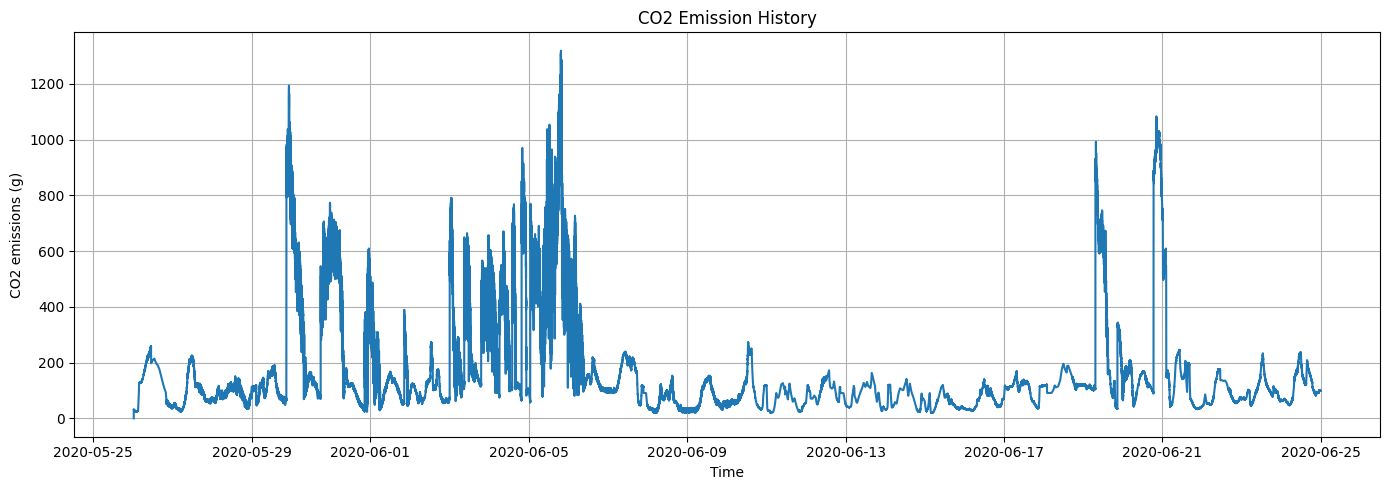

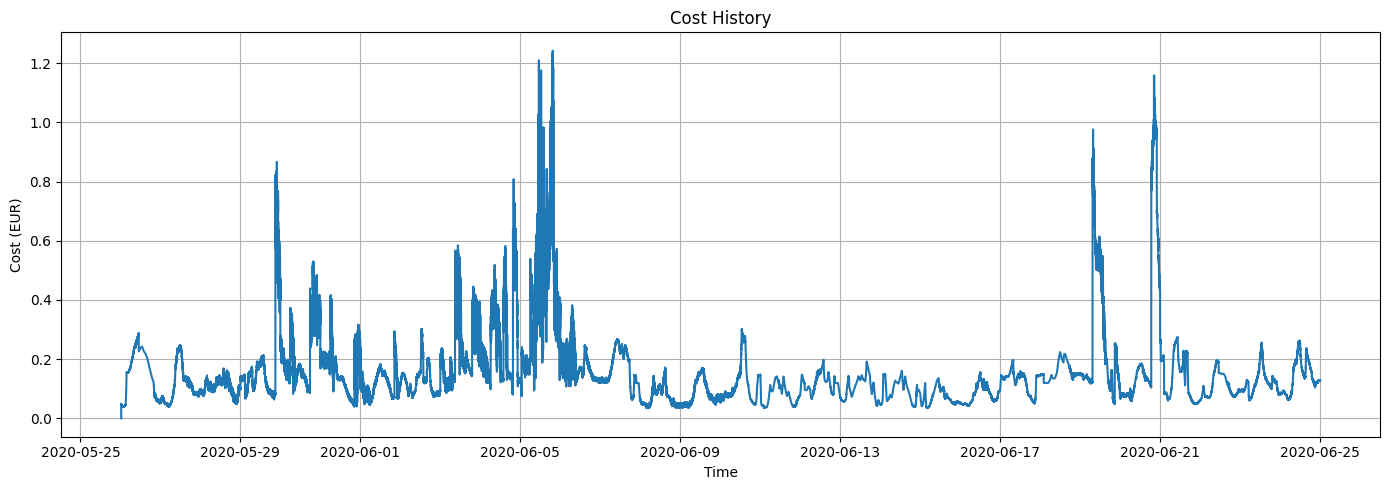

In [3]:
####       SIMULATION 2      ####

# In this simulation, the battery is used as storage for renewable energy.
# All available renewable energy is used first to cover the load.
# If renewable generation exceeds the load, the surplus is stored in the battery.
# If renewable generation is not sufficient, the battery is discharged first,
# and the remaining demand is supplied by the grid.
#
# Cost and CO2 contributions are included for:
# - renewable generation,
# - battery usage,
# - grid energy.
#
# Renewable cost and CO2 are computed for all renewable energy produced,
# including curtailed energy.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from utils.renewable_real import RenewableModels
from utils.co2 import CarbonIntensityModels
# from utils.carbonENTSOE import CarbonIntensityENTSOE
from utils.battery_model import Battery
from utils.price_model import PriceModel


# ---------------------------
# LOAD DATASET
# ---------------------------

df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")
# df = pd.read_csv("cluster_power_only_nodes.csv")

# Parse timestamps and compute the duration of each time step in hours
df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)


# ---------------------------
# ADD ELECTRICITY PRICES
# ---------------------------

price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# ---------------------------
# RENEWABLE COST / CO2 PARAMETERS
# ---------------------------

SOLAR_COST_EUR_PER_KWH = 0.05
WIND_COST_EUR_PER_KWH = 0.04

SOLAR_CO2_G_PER_KWH = 50.0
WIND_CO2_G_PER_KWH = 34.0


# ---------------------------
# SIMULATION PARAMETERS
# ---------------------------

THRESHOLD = 400000              # W
BATTERY_CAPACITY = 3_200_000    # Wh

# Alternative parameter ranges used during development
# list_thresholds = [300000, 400000, 500000]
# list_battery_capacity = [800_000, 1_600_000, 3_200_000, 6_400_000]
# list_renewables = [(200000, 250000), (300000, 350000), (400000, 450000)]

list_thresholds = [200000, 400000]
list_battery_capacity = [1_600_000, 3_200_000, 6_400_000]
list_renewables = [(200000, 250000), (400000, 450000)]

# Debug/single-scenario configuration
# list_thresholds = [250000]
# list_battery_capacity = [3_200_000]
# list_renewables = [(300000, 350000)]


results = []


# ---------------------------
# RUN SIMULATIONS
# ---------------------------

for THRESHOLD in list_thresholds:
    for BATTERY_CAPACITY in list_battery_capacity:
        for p_max_ren in list_renewables:

            # Initialize the battery model
            battery = Battery(
                capacity_wh=BATTERY_CAPACITY,
                initial_charge_wh=BATTERY_CAPACITY / 2,
                max_charge_rate_w=BATTERY_CAPACITY,
                max_discharge_rate_w=BATTERY_CAPACITY,
            )

            total_cost = 0.0
            total_co2_g = 0.0

            battery_history = []
            time_history = []
            curtailment_history = []
            cost_history = []
            co2_history_g = []

            # ---------------------------
            # ADD RENEWABLE GENERATION
            # ---------------------------

            rm = RenewableModels()
            df["P_wind"] = rm.wind_from_openmeteo(df, p_max_ren[0])
            df["P_solar"] = rm.solar_from_openmeteo(df, p_max_ren[1])
            df["P_ren"] = df["P_solar"] + df["P_wind"]

            # ---------------------------
            # ADD GRID CARBON INTENSITY
            # ---------------------------

            cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
            df["co2_intensity"] = cm.co2_from_csv(df)

            # Alternative ENTSO-E-based carbon-intensity source
            # cm = CarbonIntensityENTSOE(api_key="---")
            # df["co2_intensity"] = cm.co2_from_entsoe(df)

            # Assumptions:
            # - max charge/discharge rates are expressed in W;
            # - battery capacity and energy values are expressed in Wh;
            # - dt is expressed in hours;
            # - the grid threshold is applied to grid import power P_grid.

            # Aggregated quantities used to analyze where cost and CO2 come from
            sum_E_green_total_Wh = 0.0
            sum_green_cost = 0.0
            sum_green_co2_g = 0.0
            sum_batt_cost = 0.0
            sum_batt_co2_g = 0.0
            sum_grid_cost = 0.0
            sum_grid_co2_g = 0.0
            sum_E_from_batt_Wh = 0.0

            # ---------------------------
            # TIME-STEP SIMULATION LOOP
            # ---------------------------

            for idx, row in df.iterrows():
                COST_LOW = row["price_base"]
                COST_HIGH = row["price_high"]
                CO2_G_PER_KWH_GRID = row["co2_intensity"]

                P_load = row["power"]
                P_wind = row["P_wind"]
                P_solar = row["P_solar"]
                P_ren = row["P_ren"]
                dt = row["dt_hours"]
                t = row["time"]

                if dt <= 0:
                    battery_history.append(battery.energy)
                    time_history.append(t)
                    curtailment_history.append(0.0)
                    cost_history.append(0.0)
                    co2_history_g.append(0.0)
                    continue

                # ---------------------------
                # RENEWABLE ENERGY PRODUCTION
                # ---------------------------

                E_wind_total = P_wind * dt
                E_solar_total = P_solar * dt
                E_green_total = E_wind_total + E_solar_total

                green_cost = (
                    (E_wind_total / 1000.0) * WIND_COST_EUR_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_COST_EUR_PER_KWH
                )

                green_co2_g = (
                    (E_wind_total / 1000.0) * WIND_CO2_G_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_CO2_G_PER_KWH
                )

                sum_E_green_total_Wh += E_green_total
                sum_green_cost += green_cost
                sum_green_co2_g += green_co2_g

                # Initialize per-step quantities
                E_charged = 0.0
                E_from_batt = 0.0
                E_curtail = 0.0
                grid_cost = 0.0
                grid_co2_g = 0.0

                # Use renewable energy first to serve the load
                P_from_ren = min(P_load, P_ren)
                P_excess_ren = max(P_ren - P_from_ren, 0.0)

                # ---------------------------
                # CASE 1: RENEWABLE SURPLUS
                # Surplus renewable energy is stored in the battery.
                # Any surplus that cannot be stored is curtailed.
                # ---------------------------

                if P_excess_ren > 0:
                    E_excess_available = P_excess_ren * dt
                    E_charged = battery.charge(P_excess_ren, dt)
                    E_curtail = max(E_excess_available - E_charged, 0.0)

                # ---------------------------
                # CASE 2: RENEWABLE DEFICIT
                # The battery is discharged first; the remaining demand is
                # supplied by the grid.
                # ---------------------------

                else:
                    P_remaining = P_load - P_from_ren
                    E_needed = P_remaining * dt

                    E_from_batt = battery.discharge(P_remaining, dt)
                    E_needed_after_batt = max(E_needed - E_from_batt, 0.0)

                    P_grid_import = E_needed_after_batt / dt if dt > 0 else 0.0

                    E_base = min(P_grid_import, THRESHOLD) * dt
                    E_peak = max(P_grid_import - THRESHOLD, 0.0) * dt
                    E_from_grid = E_base + E_peak

                    grid_cost = E_base * COST_LOW + E_peak * COST_HIGH
                    grid_co2_g = (E_from_grid / 1000.0) * CO2_G_PER_KWH_GRID

                sum_grid_cost += grid_cost
                sum_grid_co2_g += grid_co2_g

                # ---------------------------
                # BATTERY COST AND CO2
                # ---------------------------

                E_batt_throughput = E_charged + E_from_batt
                batt_cost = battery.step_cost(dt, E_batt_throughput)
                batt_co2_g = battery.step_co2_g(dt, E_batt_throughput)

                sum_E_from_batt_Wh += E_from_batt
                sum_batt_cost += batt_cost
                sum_batt_co2_g += batt_co2_g

                # ---------------------------
                # STEP TOTALS
                # ---------------------------

                step_cost = green_cost + grid_cost + batt_cost
                step_co2_g = green_co2_g + grid_co2_g + batt_co2_g

                total_cost += step_cost
                total_co2_g += step_co2_g

                cost_history.append(step_cost)
                co2_history_g.append(step_co2_g)
                curtailment_history.append(E_curtail)

                # Update slow battery dynamics
                battery.step(dt)

                # Store state after the time step
                battery_history.append(battery.energy)
                time_history.append(t)

            # ---------------------------
            # STORE SCENARIO RESULTS
            # ---------------------------

            info = battery.info()
            results.append({
                "threshold": THRESHOLD,
                "battery_capacity": BATTERY_CAPACITY,
                "pmaxwind": p_max_ren[0],
                "pmaxsun": p_max_ren[1],
                "costo_euro": round(total_cost, 3),
                "co2_kg": round(total_co2_g / 1000, 3),
                "SOC_finale": round(info["SOC"], 3),
                "capacity_ratio": round(info["capacity_Wh"] / BATTERY_CAPACITY, 3),
                "sum_curtailment": round(sum(curtailment_history), 3),
                "battery_history": round(sum(battery_history), 3),
                "E_green_total_Wh": round(df["P_ren"].mul(df["dt_hours"]).sum(), 3),
                "E_from_batt_Wh": round(sum_E_from_batt_Wh, 3),
                "E_from_batt_kWh": round(sum_E_from_batt_Wh / 1000.0, 3),
                "green_cost_total_euro": round(sum_green_cost, 3),
                "green_co2_total_kg": round(sum_green_co2_g / 1000, 3),
                "battery_cost_total_euro": round(sum_batt_cost, 3),
                "battery_co2_total_kg": round(sum_batt_co2_g / 1000, 3),
                "grid_cost_total_euro": round(sum_grid_cost, 3),
                "grid_co2_total_kg": round(sum_grid_co2_g / 1000, 3)
            })


# ---------------------------
# SAVE RESULTS
# ---------------------------

pd.DataFrame(results).to_csv("outputSim/results_sim2.csv", index=False)


# ---------------------------
# PLOT: CLUSTER POWER AND BATTERY STATE OF CHARGE
# ---------------------------

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

plt.title("Cluster Power and Battery State of Charge Over Time")

# Combined legend
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()


# ---------------------------
# PLOT: GRID CARBON INTENSITY
# ---------------------------

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["co2_intensity"])
plt.xlabel("Time")
plt.ylabel("CO2 intensity")
plt.title("CO2 Intensity in Northern Italy")
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------
# PLOT: RENEWABLE POWER
# ---------------------------

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["P_ren"])
plt.xlabel("Time")
plt.ylabel("Renewable Power (W)")
plt.title("Renewable Generation")
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------
# PLOT: CO2 EMISSIONS
# ---------------------------

plt.figure(figsize=(14, 5))
plt.plot(time_history, co2_history_g)
plt.xlabel("Time")
plt.ylabel("CO2 emissions (g)")
plt.title("CO2 Emission History")
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------
# PLOT: COST
# ---------------------------

plt.figure(figsize=(14, 5))
plt.plot(time_history, cost_history)
plt.xlabel("Time")
plt.ylabel("Cost (EUR)")
plt.title("Cost History")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
####       SIMULATION 3      ####

# In this simulation, the battery is used as storage for renewable energy.
#
# Logic:
# 1) use all available renewable generation to cover the load
# 2) if renewable generation exceeds the load, charge the battery
# 3) if renewable generation is not sufficient, use the battery
# 4) if demand is still not fully covered:
#       - use the grid below the threshold
#       - use the generator and/or the grid above the threshold
#
# The following contributions are included:
# - battery cost and CO2
# - renewable generation cost and CO2
# - grid cost and CO2
# - generator cost and CO2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from utils.renewable_real import RenewableModels
from utils.co2 import CarbonIntensityModels
#from utils.carbonENTSOE import CarbonIntensityENTSOE
from utils.battery_model import Battery
from utils.generator_model import Generator
from utils.price_model import PriceModel


# ---------------------------
# LOAD DATASET
# ---------------------------

df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")
# df = pd.read_csv("cluster_power_only_nodes.csv")

# Parse timestamps and compute the duration of each time step in hours
df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)


# ---------------------------
# ADD ELECTRICITY PRICES
# ---------------------------

price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# ---------------------------
# SIMULATION PARAMETERS
# ---------------------------

# Alternative parameter ranges used during development
# list_thresholds = [200000, 300000, 400000, 500000]
# list_battery_capacity = [800_000, 1_600_000, 3_200_000, 6_400_000]
# list_renewables = [(200000,250000), (300000,350000), (400000,450000)]

list_thresholds = [200000, 400000]
list_battery_capacity = [1_600_000, 3_200_000, 6_400_000]
list_renewables = [(200000, 250000), (400000, 450000)]

# Debug/single-scenario configuration
# list_thresholds = [250000]
# list_battery_capacity = [3_200_000]
# list_renewables = [(300000,350000)]


# ---------------------------
# RENEWABLE ENERGY PARAMETERS
# Simplified levelized/lifecycle cost and CO2 factors
# ---------------------------

SOLAR_COST_EUR_PER_KWH = 0.05
WIND_COST_EUR_PER_KWH = 0.04

SOLAR_CO2_G_PER_KWH = 50.0
WIND_CO2_G_PER_KWH = 34.0


results = []


# ---------------------------
# RUN SIMULATIONS
# ---------------------------

for THRESHOLD in list_thresholds:
    for BATTERY_CAPACITY in list_battery_capacity:
        for p_max_ren in list_renewables:

            # ---------------------------
            # BATTERY MODEL
            # ---------------------------

            battery = Battery(
                capacity_wh=BATTERY_CAPACITY,
                initial_charge_wh=BATTERY_CAPACITY / 2,
                max_charge_rate_w=BATTERY_CAPACITY,
                max_discharge_rate_w=BATTERY_CAPACITY,
            )

            # ---------------------------
            # GENERATOR MODEL
            # ---------------------------

            generator = Generator(
                max_power_w=500000,
                min_power_w=50000,
                efficiency=0.4,
                fuel_cost_per_wh=0.00025,
                co2_g_per_kwh=450
            )

            # ---------------------------
            # TOTAL METRICS
            # ---------------------------

            total_cost = 0.0
            total_co2_g = 0.0

            # Energy, cost, and CO2 breakdown
            sum_E_green_total_Wh = 0.0
            sum_green_cost = 0.0
            sum_green_co2_g = 0.0

            sum_batt_cost = 0.0
            sum_batt_co2_g = 0.0

            sum_grid_cost = 0.0
            sum_grid_co2_g = 0.0

            sum_gen_cost = 0.0
            sum_gen_co2_g = 0.0

            sum_E_from_grid = 0.0
            sum_E_from_gen = 0.0
            sum_E_from_batt = 0.0
            sum_E_batt_charged = 0.0

            # Time histories
            battery_history = []
            time_history = []
            curtailment_history = []
            cost_history = []
            gen_use_history = []
            battery_use_history = []
            co2_history_g = []


            # ---------------------------
            # ADD RENEWABLE GENERATION
            # ---------------------------

            rm = RenewableModels()
            df["P_wind"] = rm.wind_from_openmeteo(df, p_max_ren[0])
            df["P_solar"] = rm.solar_from_openmeteo(df, p_max_ren[1])
            df["P_ren"] = df["P_solar"] + df["P_wind"]


            # ---------------------------
            # ADD GRID CARBON INTENSITY
            # ---------------------------

            cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
            df["co2_intensity"] = cm.co2_from_csv(df)

            # Alternative ENTSO-E-based carbon-intensity source
            # cm = CarbonIntensityENTSOE(api_key="---")
            # df["co2_intensity"] = cm.co2_from_entsoe(df)


            # ---------------------------
            # TIME-STEP SIMULATION LOOP
            # ---------------------------

            for idx, row in df.iterrows():
                COST_LOW = row["price_base"]
                COST_HIGH = row["price_high"]
                CO2_G_PER_KWH_GRID = row["co2_intensity"]

                P_load = row["power"]       # W
                P_wind = row["P_wind"]      # W
                P_solar = row["P_solar"]    # W
                P_ren = row["P_ren"]        # W
                dt = row["dt_hours"]        # h
                t = row["time"]

                if dt <= 0:
                    battery_history.append(battery.energy)
                    time_history.append(t)
                    curtailment_history.append(0.0)
                    cost_history.append(0.0)
                    co2_history_g.append(0.0)
                    gen_use_history.append(0.0)
                    battery_use_history.append(0.0)
                    continue


                # ==================================================
                # 0) RENEWABLE ENERGY COST AND CO2
                # Cost and CO2 are attributed to total renewable production.
                # ==================================================

                E_wind_total = P_wind * dt
                E_solar_total = P_solar * dt
                E_green_total = E_wind_total + E_solar_total

                green_cost = (
                    (E_wind_total / 1000.0) * WIND_COST_EUR_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_COST_EUR_PER_KWH
                )

                green_co2_g = (
                    (E_wind_total / 1000.0) * WIND_CO2_G_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_CO2_G_PER_KWH
                )

                sum_E_green_total_Wh += E_green_total
                sum_green_cost += green_cost
                sum_green_co2_g += green_co2_g


                # Initialize per-step contributions
                E_charged = 0.0
                E_from_batt = 0.0
                E_curtail = 0.0

                E_from_gen = 0.0
                E_from_grid = 0.0

                cost_grid = 0.0
                cost_gen = 0.0
                co2_grid = 0.0
                co2_gen = 0.0


                # ==================================================
                # 1) USE RENEWABLES TO COVER THE LOAD
                # ==================================================

                P_from_ren = min(P_load, P_ren)
                P_excess_ren = max(P_ren - P_from_ren, 0.0)


                # ==================================================
                # 1a) RENEWABLE SURPLUS -> BATTERY
                # ==================================================

                if P_excess_ren > 0:
                    E_excess_available = P_excess_ren * dt
                    E_charged = battery.charge(P_excess_ren, dt)
                    E_curtail = max(E_excess_available - E_charged, 0.0)

                else:

                    # ==================================================
                    # 2) RENEWABLE DEFICIT -> BATTERY
                    # ==================================================

                    P_remaining = P_load - P_from_ren
                    E_needed = P_remaining * dt

                    E_from_batt = battery.discharge(P_remaining, dt)
                    E_needed_after_batt = max(E_needed - E_from_batt, 0.0)

                    P_after_batt = E_needed_after_batt / dt if dt > 0 else 0.0


                    # ==================================================
                    # 3) GRID + GENERATOR POLICY
                    # ==================================================

                    # Option 1: use the generator only when economically convenient
                    # according to the peak electricity price.
                    # This corresponds to a simplified soft-constraint dispatch.
                    # use_generator = COST_HIGH > generator.fuel_cost_per_wh

                    # Option 2: always use the generator when the threshold is exceeded.
                    # This corresponds to a hard grid-cap policy.
                    use_generator = 1

                    # Portion below the threshold is supplied by the grid.
                    P_grid_base = min(P_after_batt, THRESHOLD)

                    # Portion above the threshold is considered peak demand.
                    P_peak = max(P_after_batt - THRESHOLD, 0.0)

                    # Generator output is limited by its maximum power.
                    if use_generator:
                        P_gen = min(P_peak, generator.max_power_w)
                    else:
                        P_gen = 0.0

                    # Any remaining peak demand is supplied by the grid.
                    P_grid_peak = P_peak - P_gen

                    # Total grid import power
                    P_grid = P_grid_base + P_grid_peak

                    # Energy contributions
                    E_from_gen = P_gen * dt
                    E_from_grid = P_grid * dt

                    E_base = P_grid_base * dt
                    E_peak = P_grid_peak * dt

                    # Grid cost
                    cost_grid = E_base * COST_LOW + E_peak * COST_HIGH

                    # Generator cost
                    cost_gen = generator.get_cost(E_from_gen)

                    # Grid CO2 emissions
                    co2_grid = (E_from_grid / 1000.0) * CO2_G_PER_KWH_GRID

                    # Generator CO2 emissions
                    co2_gen = generator.get_co2(E_from_gen / 1000.0)


                # ==================================================
                # 4) BATTERY COST AND CO2
                # Throughput is computed as charge + discharge energy.
                # ==================================================

                E_batt_throughput = E_charged + E_from_batt

                batt_cost = battery.step_cost(dt, E_batt_throughput)
                batt_co2_g = battery.step_co2_g(dt, E_batt_throughput)

                sum_batt_cost += batt_cost
                sum_batt_co2_g += batt_co2_g


                # Update grid and generator breakdown
                sum_grid_cost += cost_grid
                sum_grid_co2_g += co2_grid
                sum_gen_cost += cost_gen
                sum_gen_co2_g += co2_gen

                sum_E_from_grid += E_from_grid
                sum_E_from_gen += E_from_gen
                sum_E_from_batt += E_from_batt
                sum_E_batt_charged += E_charged


                # ==================================================
                # 5) STEP TOTALS
                # ==================================================

                step_cost = green_cost + batt_cost + cost_grid + cost_gen
                step_co2_g = green_co2_g + batt_co2_g + co2_grid + co2_gen

                total_cost += step_cost
                total_co2_g += step_co2_g


                # Store time-step histories
                curtailment_history.append(E_curtail)
                cost_history.append(step_cost)
                co2_history_g.append(step_co2_g)

                battery_history.append(battery.energy)
                time_history.append(t)
                gen_use_history.append(E_from_gen)
                battery_use_history.append(E_from_batt)

                # Update slow battery dynamics
                battery.step(dt)


            # ---------------------------
            # STORE SCENARIO RESULTS
            # ---------------------------

            info = battery.info()

            results.append({
                "threshold": THRESHOLD,
                "battery_capacity": BATTERY_CAPACITY,
                "pmaxwind": p_max_ren[0],
                "pmaxsun": p_max_ren[1],

                "costo_euro": round(total_cost, 3),
                "co2_kg": round(total_co2_g / 1000.0, 3),

                "green_energy_total_Wh": round(sum_E_green_total_Wh, 3),
                "green_cost_total_euro": round(sum_green_cost, 3),
                "green_co2_total_kg": round(sum_green_co2_g / 1000.0, 3),

                "battery_cost_total_euro": round(sum_batt_cost, 3),
                "battery_co2_total_kg": round(sum_batt_co2_g / 1000.0, 3),

                "grid_cost_total_euro": round(sum_grid_cost, 3),
                "grid_co2_total_kg": round(sum_grid_co2_g / 1000.0, 3),

                "generator_cost_total_euro": round(sum_gen_cost, 3),
                "generator_co2_total_kg": round(sum_gen_co2_g / 1000.0, 3),

                "E_from_grid_Wh": round(sum_E_from_grid, 3),
                "E_from_gen_Wh": round(sum_E_from_gen, 3),
                "E_from_batt_Wh": round(sum_E_from_batt, 3),
                "E_to_batt_Wh": round(sum_E_batt_charged, 3),

                "SOC_finale": round(info["SOC"], 3),
                "capacity_ratio": round(info["capacity_Wh"] / BATTERY_CAPACITY, 3),

                "sum_curtailment_Wh": round(sum(curtailment_history), 3),
                "battery_use_history_Wh": round(sum(battery_use_history), 3),
                "gen_use_history_Wh": round(sum(gen_use_history), 3),
            })


# ---------------------------
# SAVE RESULTS
# ---------------------------

pd.DataFrame(results).to_csv("outputSim/results_sim3_HC.csv", index=False)

In [ ]:
# To test RL optimizing saved model

obs, _ = env.reset()
done = False
total_cost_rl = 0

while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_cost_rl += -reward

print("Total cost RL:", total_cost_rl)